<a href="https://colab.research.google.com/github/karthiksai2121/DEFAULTPREDICTION-OF-CREDITCARD-CLIENTS/blob/main/credit_card_default_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INSTALLING AND IMPORTING LIBRARIES

This section installs required packages and imports all libraries used for data preprocessing, visualisation, machine learning modelling, class imbalance handling, and performance evaluation.


In [ ]:
!pip install -q xgboost lightgbm catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier
)


from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


# Loading the Dataset and Initial Exploration.


In [ ]:
Data = "https://raw.githubusercontent.com/karthiksai2121/DEFAULTPREDICTION-OF-CREDITCARD-CLIENTS/refs/heads/main/UCI_Credit_Card.csv"
df = pd.read_csv(Data)


print("First 5 Rows:")
display(df.head())

print("Dataset Shape:", df.shape)


print("\nColumn Names:")
print(list(df.columns))


print("\nMissing Values:")
display(df.isnull().sum().to_frame(name="Missing Count"))


print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
display(df.describe().T)

First 5 Rows:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


Dataset Shape: (30000, 25)

Column Names:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']

Missing Values:


,Missing Count
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2       

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


# Exploratory Data Analysis


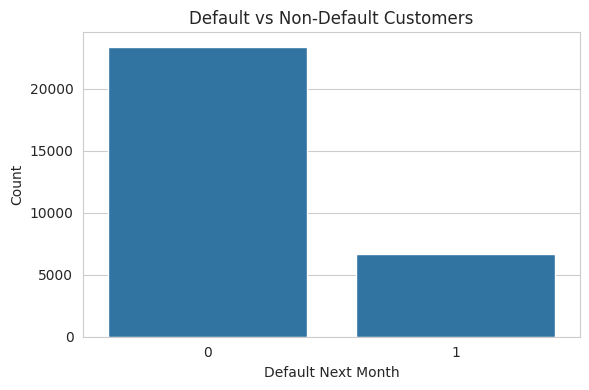

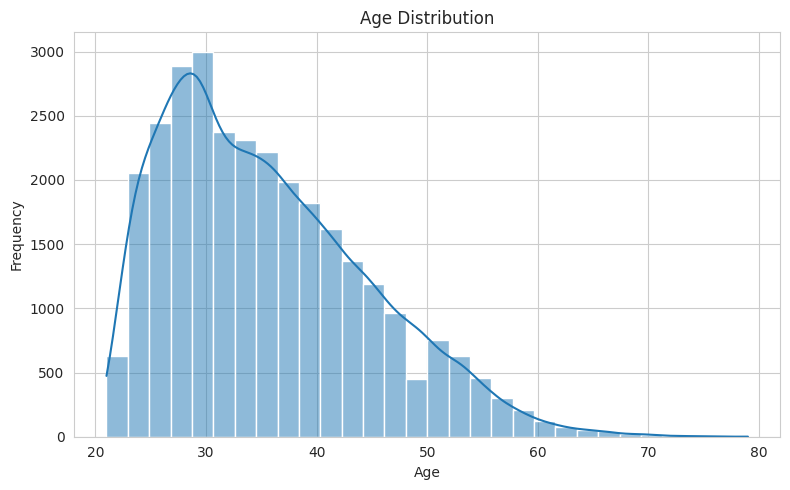

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='default.payment.next.month', data=df)
plt.title("Default vs Non-Default Customers")
plt.xlabel("Default Next Month")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
print("\n")

plt.figure(figsize=(8,5))
sns.histplot(df['AGE'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Correlation Analysis of Financial and Repayment Variables

**This heatmap visualises the relationships between numerical features in the dataset, helping identify patterns, dependencies, and variables associated with credit default behaviour.**

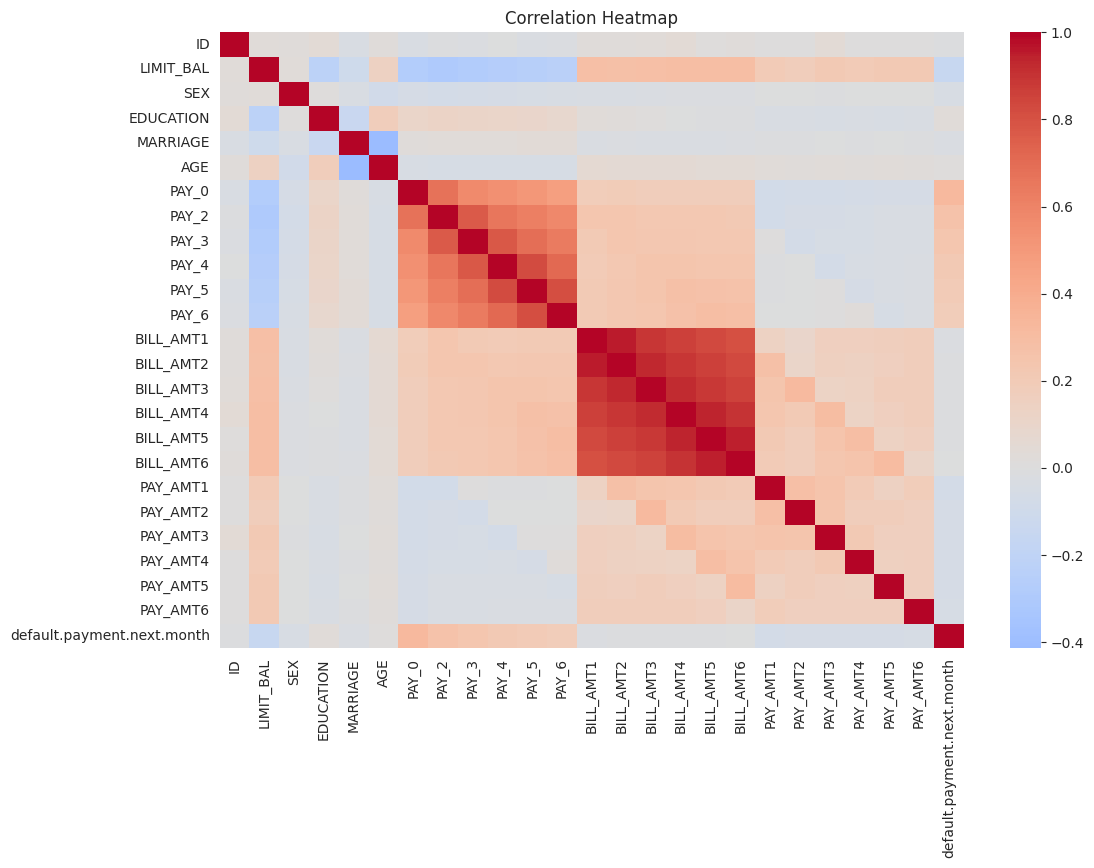

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

# Gender-Based Default Behaviour Analysis

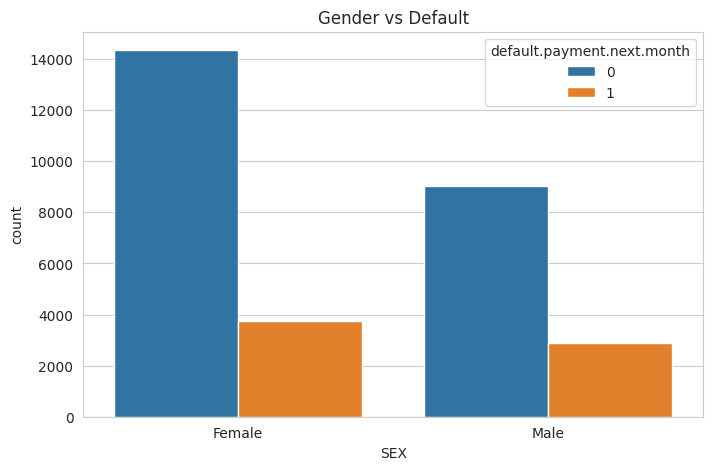

In [ ]:
df_plot = df.copy()
df_plot["SEX"] = df_plot["SEX"].map({1:"Male", 2:"Female"})

plt.figure(figsize=(8,5))
sns.countplot(x="SEX", hue="default.payment.next.month", data=df_plot)
plt.title("Gender vs Default")
plt.show()

# DATA PREPROCESSING AND DISTRIBUTION OF CLASS

       CLASS DISTRIBUTION SUMMARY
---------------------------------------------
    No Default  (0)  →  23,364  |  77.88%
       Default  (1)  →   6,636  |  22.12%
---------------------------------------------
         Total       →  30,000  |  100.00%

  Imbalance Ratio  →  3.52 : 1  (No Default : Default)




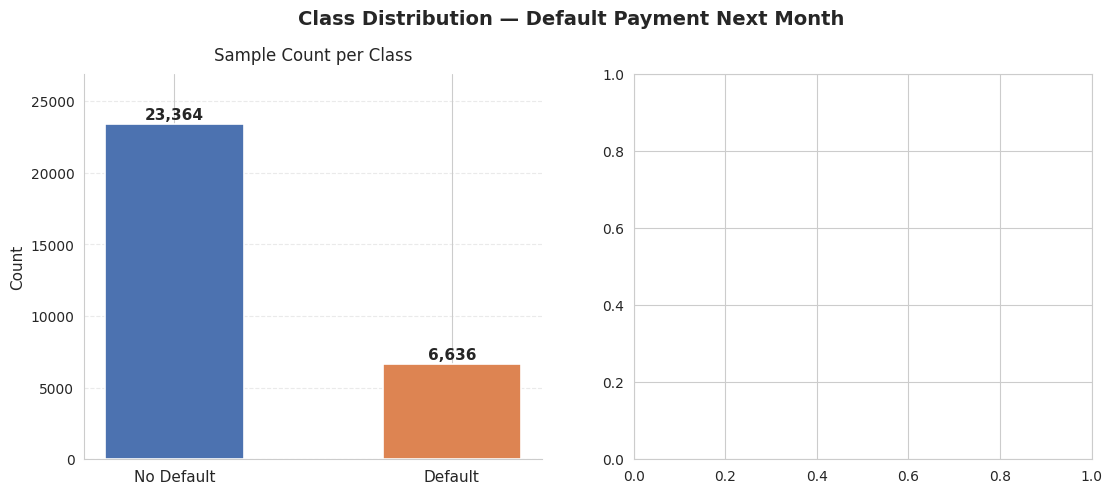

In [ ]:
if "ID" in df.columns:
    df = df.drop("ID", axis=1)
    X = df.drop("default.payment.next.month", axis=1)
y = df["default.payment.next.month"]

print("       CLASS DISTRIBUTION SUMMARY")
print("-" * 45)
class_counts  = y.value_counts()
class_labels  = {0: "No Default", 1: "Default"}
total         = len(y)

for cls, count in class_counts.items():
    label = class_labels.get(cls, str(cls))
    pct   = count / total * 100
    print(f"  {label:>12}  ({cls})  →  {count:>6,}  |  {pct:.2f}%")

print("-" * 45)
print(f"  {'Total':>12}       →  {total:>6,}  |  100.00%")
imbalance_ratio = class_counts[0] / class_counts[1]
print(f"\n  Imbalance Ratio  →  {imbalance_ratio:.2f} : 1  (No Default : Default)")
print("\n")


palette = {0: "#4C72B0", 1: "#DD8452"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Class Distribution — Default Payment Next Month",
             fontsize=14, fontweight="bold", y=1.01)

ax1 = axes[0]
bars = ax1.bar(
    [class_labels[c] for c in class_counts.index],
    class_counts.values,
    color=[palette[c] for c in class_counts.index],
    edgecolor="white",
    linewidth=1.2,
    width=0.5
)
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 120,
        f"{int(height):,}",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold"
    )
ax1.set_title("Sample Count per Class", fontsize=12, pad=10)
ax1.set_ylabel("Count", fontsize=11)
ax1.set_ylim(0, class_counts.max() * 1.15)
ax1.spines[["top", "right"]].set_visible(False)
ax1.tick_params(axis="x", labelsize=11)
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# Logistic Regression: Training and Evaluation

In [ ]:
#Train-Test SpliT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nLogistic Regression")

lr = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    class_weight="balanced"
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


Logistic Regression
Accuracy: 0.6796666666666666

Confusion Matrix:
[[3255 1418]
 [ 504  823]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.70      0.77      4673
           1       0.37      0.62      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000



## Model Comparison for Decision Tree, KNN, and SVM

In [ ]:

print("\n Model Comparison ")

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42)
}

results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, pred)

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred))
    print("Classification Report:")
    print(classification_report(y_test, pred))


    results.append((name, acc))

print("\nSummary")
results = sorted(results, key=lambda x: x[1], reverse=True)

for name, acc in results:
    print(f"{name}: {acc:.4f}")


 Model Comparison 

Decision Tree
Accuracy: 0.7151666666666666
Confusion Matrix:
[[3745  928]
 [ 781  546]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.81      4673
           1       0.37      0.41      0.39      1327

    accuracy                           0.72      6000
   macro avg       0.60      0.61      0.60      6000
weighted avg       0.73      0.72      0.72      6000


KNN
Accuracy: 0.7928333333333333
Confusion Matrix:
[[4284  389]
 [ 854  473]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      4673
           1       0.55      0.36      0.43      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.64      0.65      6000
weighted avg       0.77      0.79      0.78      6000


SVM
Accuracy: 0.816
Confusion Matrix:
[[4447  226]
 [ 878  449]]
Classification Report:
              precision

# Random Forest Performance with and without SMOTE for Class Imbalance

In [ ]:
print("\n Random Forest")

from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


print("\n SMOTE + Random Forest")

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nBefore SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())

rf_sm = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_sm.fit(X_train_sm, y_train_sm)
y_pred_sm = rf_sm.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_sm), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_sm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_sm))


 Random Forest
Accuracy: 0.8127

Confusion Matrix:
[[4393  280]
 [ 844  483]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.63      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000


 SMOTE + Random Forest

Before SMOTE:
default.payment.next.month
0    18691
1     5309
Name: count, dtype: int64

After SMOTE:
default.payment.next.month
0    18691
1    18691
Name: count, dtype: int64
Accuracy: 0.797

Confusion Matrix:
[[4156  517]
 [ 701  626]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.87      4673
           1       0.55      0.47      0.51      1327

    accuracy                           0.80      6000
   macro avg       0.70      0.68      0.69      6000
weighted 

# Feature Importance Analysis (Top 10 Predictive Features)


Top 10 Important Features:
      Feature  Importance
5       PAY_0    0.097754
4         AGE    0.066378
0   LIMIT_BAL    0.060220
11  BILL_AMT1    0.059563
12  BILL_AMT2    0.054502
13  BILL_AMT3    0.051496
17   PAY_AMT1    0.051388
16  BILL_AMT6    0.050669
14  BILL_AMT4    0.050222
15  BILL_AMT5    0.050159


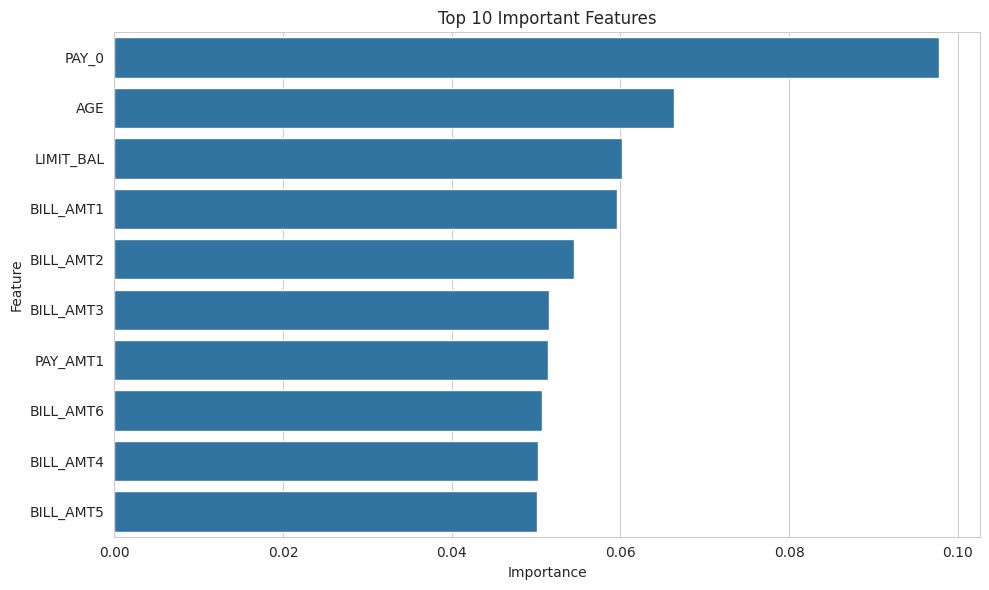

In [ ]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 10 Important Features:")
print(importance_df.head(10))

plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(10), x="Importance", y="Feature")
plt.title("Top 10 Important Features")
plt.tight_layout()
plt.show()

# Advanced Boosting Models: XGBoost vs LightGBM Performance Evaluation

In [ ]:
import warnings
warnings.filterwarnings("ignore")

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("\nXGBoost")
print("Accuracy:", round(accuracy_score(y_test, y_pred_xgb), 4))
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))



lgbm = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)

print("\n LightGBM")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lgbm), 4))
print(confusion_matrix(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))


XGBoost
Accuracy: 0.7702
[[3832  841]
 [ 538  789]]
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      4673
           1       0.48      0.59      0.53      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.77      0.78      6000


 LightGBM
Accuracy: 0.765
[[3793  880]
 [ 530  797]]
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      4673
           1       0.48      0.60      0.53      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.77      0.77      6000



# Ensemble Learning Models: CatBoost & Voting Classifier Performance Evaluation

In [ ]:
cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=0
)

cat.fit(X_train, y_train)
y_pred_cat = cat.predict(X_test)

print(" CatBoost")
print("Accuracy:", round(accuracy_score(y_test, y_pred_cat), 4))
print(confusion_matrix(y_test, y_pred_cat))
print(classification_report(y_test, y_pred_cat))

vote = VotingClassifier(
    estimators=[
        ("xgb", XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos,
                              eval_metric="logloss", random_state=42)),
        ("lgbm", LGBMClassifier(n_estimators=100, class_weight="balanced",
                                random_state=42, verbose=-1)),
        ("rf", RandomForestClassifier(n_estimators=100,
                                      class_weight="balanced",
                                      random_state=42))
    ],
    voting="soft"
)

vote.fit(X_train, y_train)
y_pred_vote = vote.predict(X_test)

print("Voting Classifier")
print("Accuracy:", round(accuracy_score(y_test, y_pred_vote), 4))
print(confusion_matrix(y_test, y_pred_vote))
print(classification_report(y_test, y_pred_vote))

 CatBoost
Accuracy: 0.768
[[3792  881]
 [ 511  816]]
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      4673
           1       0.48      0.61      0.54      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.77      0.78      6000

Voting Classifier
Accuracy: 0.7983
[[4104  569]
 [ 641  686]]
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      4673
           1       0.55      0.52      0.53      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.70      0.70      6000
weighted avg       0.79      0.80      0.80      6000



# Random Forest Hyperparameter Tuning using GridSearchCV

In [ ]:
print("\n Hyperparameter Tuning (Random Forest) ")

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("\n Best Parameters:")
print(grid_search.best_params_)


y_pred_best = best_rf.predict(X_test)

print("\nTuned Model Performance")
print("Accuracy:", round(accuracy_score(y_test, y_pred_best), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))


 Hyperparameter Tuning (Random Forest) 
Fitting 3 folds for each of 24 candidates, totalling 72 fits

 Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Tuned Model Performance
Accuracy: 0.8172

Confusion Matrix:
[[4441  232]
 [ 865  462]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.35      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000



##ROC Curve Comparison of Advanced Models

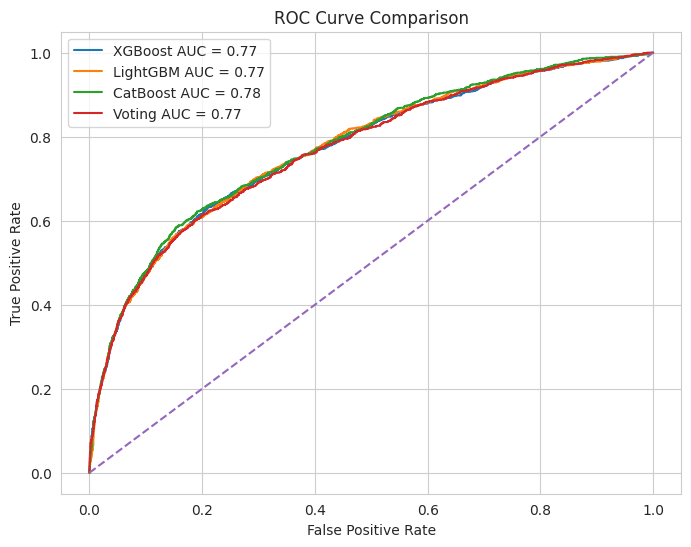

In [ ]:


plt.figure(figsize=(8,6))

# XGBoost
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost AUC = %.2f" % auc(fpr_xgb, tpr_xgb))

# LightGBM
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_lgbm)
plt.plot(fpr_lgbm, tpr_lgbm, label="LightGBM AUC = %.2f" % auc(fpr_lgbm, tpr_lgbm))

# CatBoost
y_prob_cat = cat.predict_proba(X_test)[:, 1]
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_prob_cat)
plt.plot(fpr_cat, tpr_cat, label="CatBoost AUC = %.2f" % auc(fpr_cat, tpr_cat))

# Voting Classifier
y_prob_vote = vote.predict_proba(X_test)[:, 1]
fpr_vote, tpr_vote, _ = roc_curve(y_test, y_prob_vote)
plt.plot(fpr_vote, tpr_vote, label="Voting AUC = %.2f" % auc(fpr_vote, tpr_vote))

# Baseline
plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# COMPARISON OF ALL MACHINE LEARNING MODELS

In [ ]:

results = []

models_dict = {
    "Logistic Regression": (lr, y_pred_lr),
    "Decision Tree": (models["Decision Tree"], models["Decision Tree"].predict(X_test)),
    "KNN": (models["KNN"], models["KNN"].predict(X_test)),
    "SVM": (models["SVM"], models["SVM"].predict(X_test)),
    "Random Forest": (rf, y_pred_rf),
    "SMOTE RF": (rf_sm, y_pred_sm),
    "Tuned RF": (best_rf, y_pred_best),
    "XGBoost": (xgb, y_pred_xgb),
    "LightGBM": (lgbm, y_pred_lgbm),
    "CatBoost": (cat, y_pred_cat),
    "Voting": (vote, y_pred_vote)
}

for name, (model, pred) in models_dict.items():
    try:
        prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, prob)
    except:
        auc = np.nan

    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        auc
    ])

comparison_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "AUC"
])

comparison_df = comparison_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)

print(" COMPARISON OF ALL MODELS")
display(
    comparison_df.style
    .format("{:.4f}", subset=["Accuracy","Precision","Recall","F1 Score","AUC"])
    .background_gradient(cmap="Greens")
)

 COMPARISON OF ALL MODELS


,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Tuned RF,0.8172,0.6657,0.3482,0.4572,0.7733
1,SVM,0.8160,0.6652,0.3384,0.4486,0.7210
2,Random Forest,0.8127,0.6330,0.3640,0.4622,0.7548
3,Voting,0.7983,0.5466,0.5170,0.5314,0.7699
4,SMOTE RF,0.7970,0.5477,0.4717,0.5069,0.7528
5,KNN,0.7928,0.5487,0.3564,0.4322,0.7014
6,XGBoost,0.7702,0.4840,0.5946,0.5336,0.7719
7,CatBoost,0.7680,0.4808,0.6149,0.5397,0.7779
8,LightGBM,0.7650,0.4753,0.6006,0.5306,0.7730
9,Decision Tree,0.7152,0.3704,0.4115,0.3899,0.6079
